In [33]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import re
from pathlib import Path

In [34]:
# 1. Loading the cleaned data of Zueriwieneu requests, neighbourhoods and population
reports_gdf = gpd.read_file("../data/cleaned/stzh.zwn_meldungen_p_cleaned.gpkg")
pop_quartiere_gdf = gpd.read_file("../data/cleaned/pop_quartiere_2013_2025.gpkg")
quartiere_gdf = gpd.read_file("../data/raw/quartiere.gpkg", layer="stzh.adm_statistische_quartiere_v")
quartiere_labels_gdf = gpd.read_file("../data/raw/quartiere.gpkg", layer="stzh.adm_statistische_quartiere_b_p")

# 2. Assign reports to their nearest neighbourhoods (a few lie just directly outside the city boarder, thus "nearest" was used instead of "within" or "intersects")
reports_quartier = gpd.sjoin_nearest(
    reports_gdf,
    pop_quartiere_gdf,
    how="left"
)

print(f"{reports_quartier['qname'].isna().sum()} reports were not assigned to a neighbourhood")

# 3. Define output file path
output_fp = Path(
    "C:/Users/lukas/OneDrive/Desktop/Privat/UZH/FS 26/Spatial Programming/sds210_project/outputs"
)

0 reports were not assigned to a neighbourhood


In [36]:
display(quartiere_labels_gdf.head())

,objid,objectid,ori,hali,vali,name,kuerzel,geometry
0,1,1,0.0,1.0,2.0,Affoltern,111,POINT (2680575.711 1253034.933)
1,2,2,0.0,1.0,2.0,Seebach,119,POINT (2683071.957 1253148.375)
2,3,3,0.0,1.0,2.0,Saatlen,121,POINT (2684968.446 1251835.404)
3,4,4,0.0,1.0,2.0,Höngg,101,POINT (2679781.451 1251349.147)
4,5,5,0.0,1.0,2.0,Wipkingen,102,POINT (2681888.652 1250165.853)


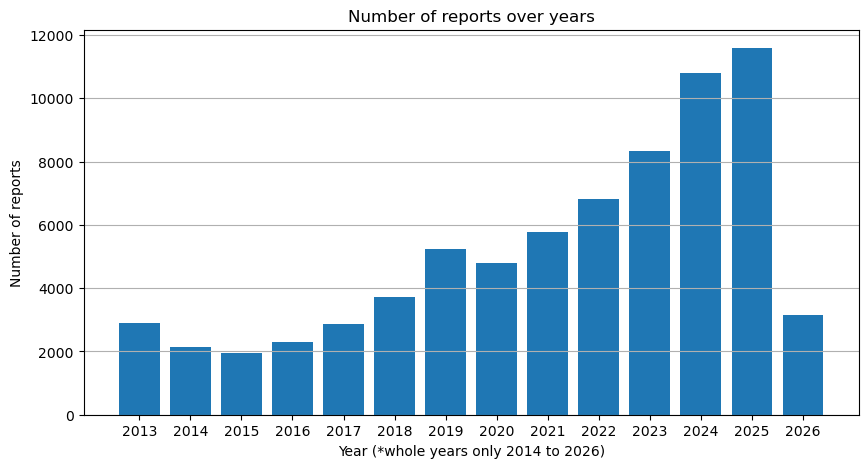

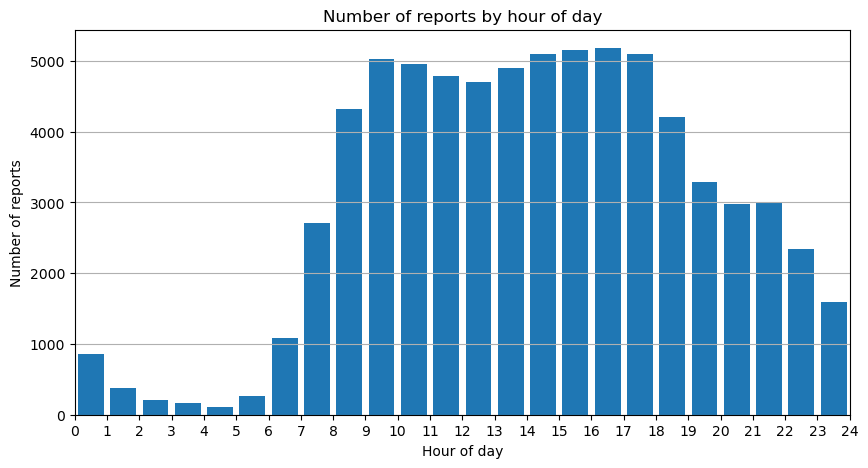

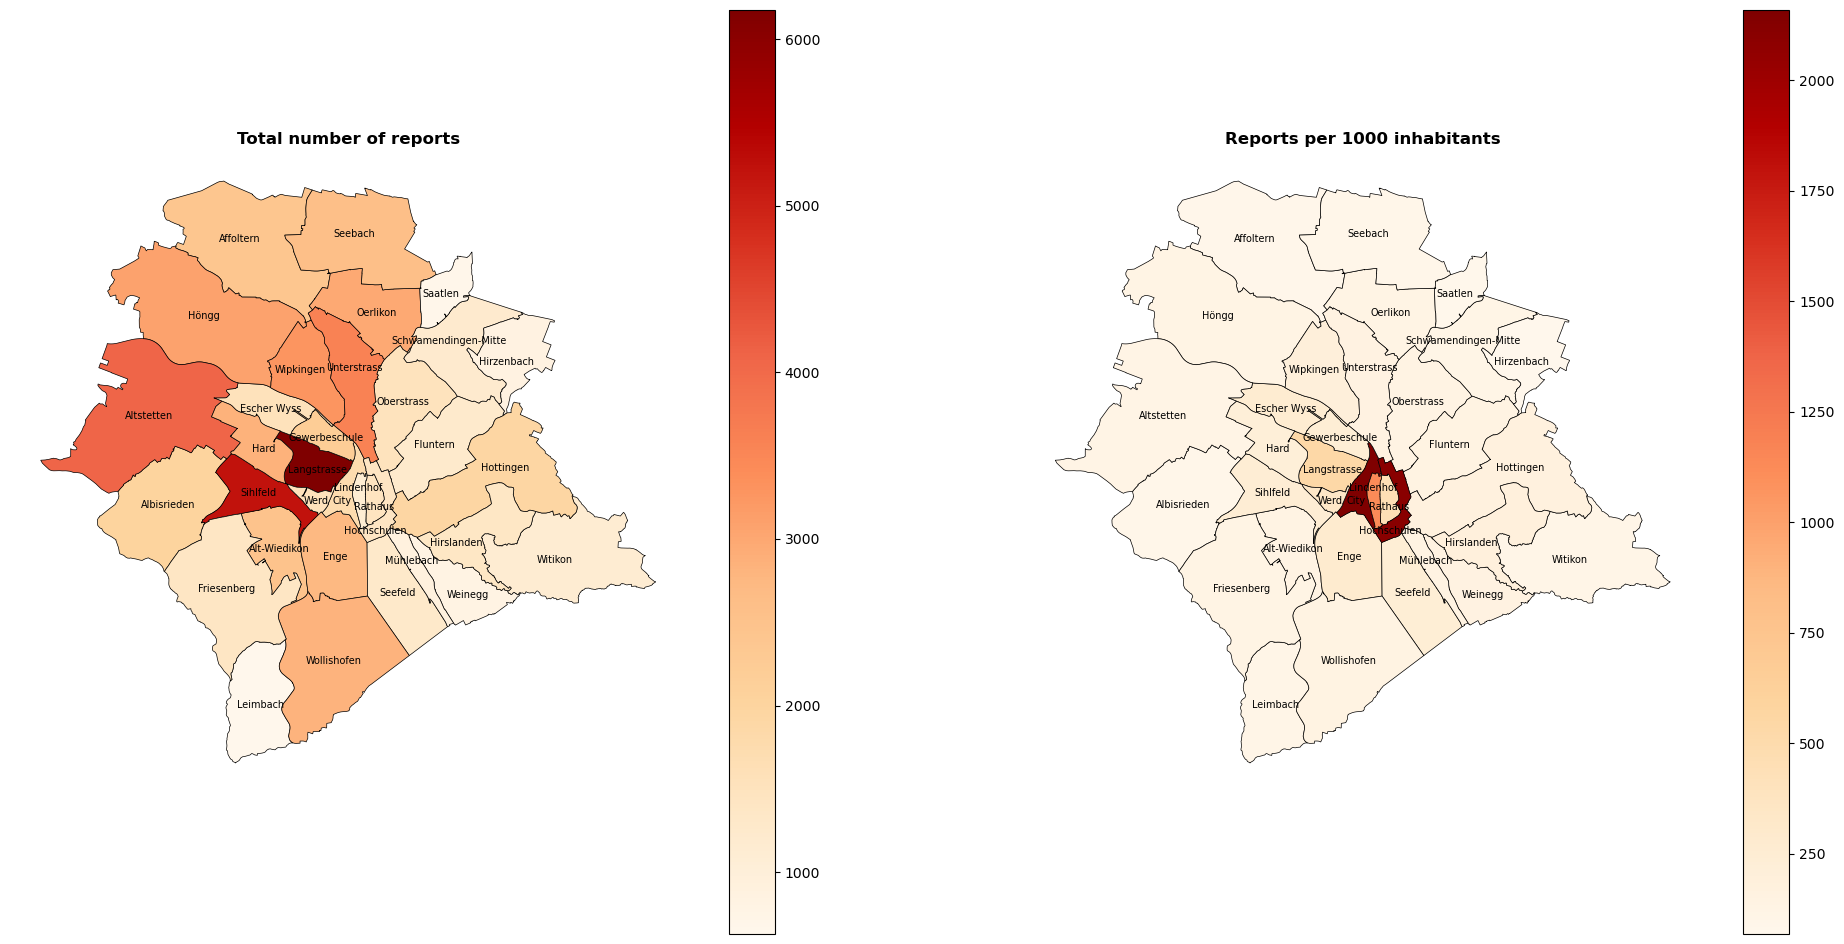

In [48]:
# (1) How does number of reports evolve over the years, diurnal and across neighbourhoods?

# Extract year
reports_gdf["year"] = (
    reports_gdf["requested_datetime"].dt.year
)

# (1.1) Count the total number of reports per year
report_counts_year = (
    reports_gdf
    .groupby("year")
    .size()
    .reset_index(name="report_count")
)

# Plot the number of reports per year with a bar chart
plt.figure(figsize=(10, 5))

plt.bar(
    report_counts_year["year"],
    report_counts_year["report_count"]
)

plt.title("Number of reports over years")
plt.xlabel("Year (*whole years only 2014 to 2026)")
plt.ylabel("Number of reports")

# every year as tick
plt.xticks(report_counts_year["year"])

plt.grid(axis="y")

# save figure to output-folder
plt.savefig(
    output_fp / "reports_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Extract hour of day
reports_gdf["hour"] = reports_gdf["requested_datetime"].dt.hour

# (1.2) Count the total number of reports per hour
report_counts_hour = (
    reports_gdf
    .groupby("hour")
    .size()
    .reset_index(name="report_count")
)

# Plot the number of reports per hour with a bar chart
plt.figure(figsize=(10, 5))

# bars centered between hour ticks
x_positions = report_counts_hour["hour"] + 0.5

plt.bar(
    x_positions,
    report_counts_hour["report_count"],
    width=0.8
)

plt.title("Number of reports by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Number of reports")

# ticks at hour boundaries
plt.xticks(range(0, 25))

plt.xlim(0, 24)

plt.grid(axis="y")

# save figure to output-folder
plt.savefig(
    output_fp / "reports_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)
        
plt.show()


# (1.3) Count total reports per neighbourhood normalized by mean population from 2013-2025

# Asses mean population over the reporting period
population_cols = [
    "2013", "2014", "2015", "2016", "2017",
    "2018", "2019", "2020", "2021", "2022",
    "2023", "2024", "2025"
]

pop_quartiere_gdf["mean_pop_2013-2025"] = (
    pop_quartiere_gdf[population_cols]
    .mean(axis=1)
)
report_counts_quartier = (
    reports_quartier
    .groupby("qname")
    .size()
    .reset_index(name="report_count")
)

# Join counts back to neighbourhood polygons/population
quartier_analysis = pop_quartiere_gdf.merge(
    report_counts_quartier,
    on="qname",
    how="left"
)

# Calculate reports per 1000 inhabitants
quartier_analysis["reports_per_1000"] = (
    quartier_analysis["report_count"]
    / quartier_analysis["mean_pop_2013-2025"]
) * 1000

# plot total reports and normalized reports as choropleths of neighbourhoods side-by-side
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# use same colormap
cmap = "OrRd"

# (Left map) total reports
quartier_analysis.plot(
    column="report_count",
    cmap=cmap,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=axes[0]
)

axes[0].set_title("Total number of reports", fontsize=12, fontweight="bold")
axes[0].axis("off")

# (Right map) reports per 1000 inhabitants
quartier_analysis.plot(
    column="reports_per_1000",
    cmap=cmap,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=axes[1]
)

axes[1].set_title("Reports per 1000 inhabitants", fontsize=12, fontweight="bold")
axes[1].axis("off")

# add neighbourhood labels from label points layer
for ax in axes:

    for idx, row in quartiere_labels_gdf.iterrows():

        x = row.geometry.x
        y = row.geometry.y

        # manual adjustments of two overlapping labels in the centre
        if row["name"] == "Lindenhof":
            y += 100

        if row["name"] == "Rathaus":
            y -= 200

        ax.text(
            x,
            y,
            row["name"],
            fontsize=7,
            ha="center",
            va="center"
        )

# save figure to output-folder
plt.savefig(
    output_fp / "choropleth_reports_combined.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

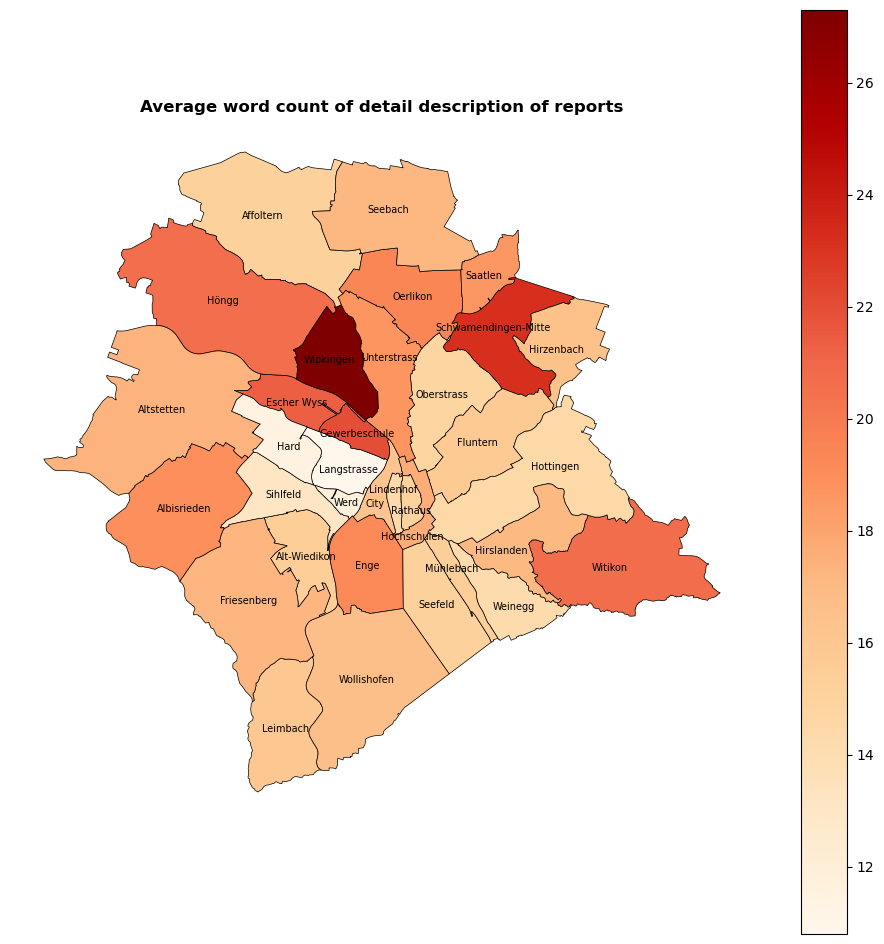

In [52]:
# (2) Which neighbourhoods make the most detailed reports (average number of words)?

# Count words in each report detail
reports_quartier["word_count"] = (
    reports_quartier["detail"]
    .str.split() # splits detail in a list of single words
    .str.len() # counts length of the list
)

# Average words per neighbourhood
avg_word_count = (
    reports_quartier
    .groupby("qname")["word_count"]
    .mean()
    .reset_index(name="avg_word_count")
    .sort_values("avg_word_count", ascending=False)
)

# Merge to quartier_analysis to map on the neighbourhod polygons
quartier_analysis = quartier_analysis.merge(
    avg_word_count,
    on="qname",
    how="left"
)

# plot report length as choropleths of neighbourhoods
fig, ax = plt.subplots(figsize=(12, 12))

# use same colormap
cmap = "OrRd"

quartier_analysis.plot(
    column="avg_word_count",
    cmap=cmap,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Average word count of detail description of reports", 
    fontsize=12, 
    fontweight="bold"
)
ax.axis("off")


# add neighbourhood labels from label points layer
for idx, row in quartiere_labels_gdf.iterrows():
    x = row.geometry.x
    y = row.geometry.y

    # manual adjustments of two overlapping labels in the centre
    if row["name"] == "Lindenhof":
        y += 100

    if row["name"] == "Rathaus":
        y -= 200

    ax.text(
        x,
        y,
        row["name"],
        fontsize=7,
        ha="center",
        va="center"
    )

# save figure to output-folder
plt.savefig(
    output_fp / "choropleth_word_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

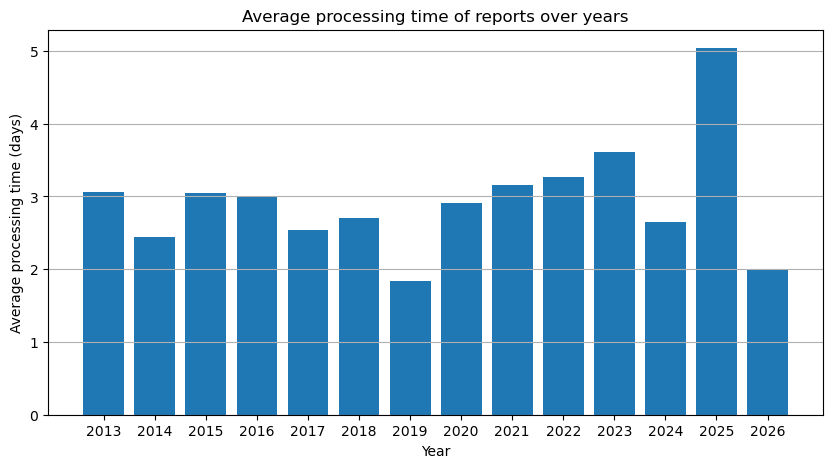

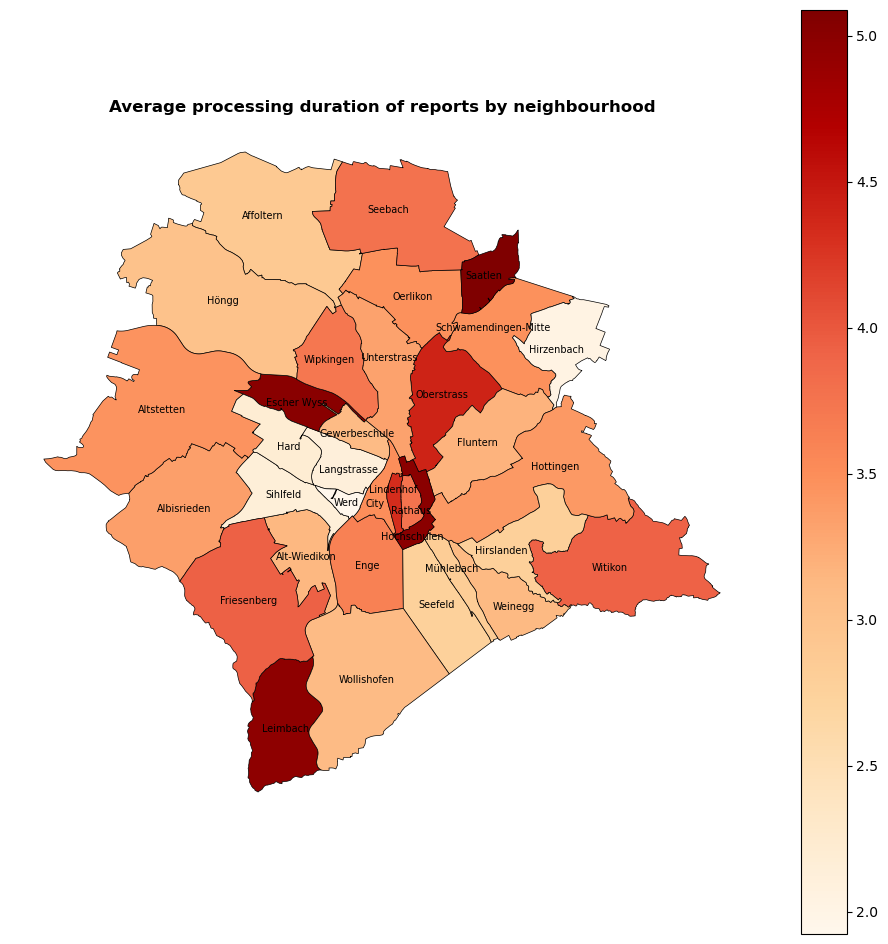

In [55]:
# (3) How long does the processing of the reports by the council take? Did it change over time and neighbourhoods? (only for reports with "status"="fixed - council")

# Define only the reports that were fixed by the municipal offices
fixed_reports = reports_quartier[
    reports_quartier["status"] == "fixed - council"
].copy()

# Calculate processing duration for these reports
fixed_reports["processing_time"] = (
    fixed_reports["updated_datetime"]
    - fixed_reports["requested_datetime"]
)

# recalcualte processing duration to decimal days
fixed_reports["processing_days"] = (
    fixed_reports["processing_time"]
    .dt.total_seconds() / (60 * 60 * 24)
)

# Extract year
fixed_reports["year"] = (
    fixed_reports["requested_datetime"].dt.year
)

# (3.1) Count the average processing duration per year
processing_time_year = (
    fixed_reports
    .groupby("year")["processing_days"]
    .mean()
    .reset_index(name="avg_processing_days")
    .sort_values("year", ascending=True)
)

# Plot the the evolution of average processing time with a bar chart
plt.figure(figsize=(10, 5))

plt.bar(
    processing_time_year["year"],
    processing_time_year["avg_processing_days"]
)

plt.title("Average processing time of reports over years")
plt.xlabel("Year")
plt.ylabel("Average processing time (days)")

# every year as tick
plt.xticks(processing_time_year["year"])
plt.grid(axis="y")

# save figure to output-folder
plt.savefig(
    output_fp / "processing_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# (3.2) Count the average processing duration per neighbourhood
processing_time_by_quartier = (
    fixed_reports
    .groupby("qname")["processing_days"]
    .mean()
    .reset_index(name="avg_processing_days")
    .sort_values("avg_processing_days", ascending=True)
)

# Merge to quartier_analysis to map on the neighbourhod polygons
quartier_analysis = quartier_analysis.merge(
    processing_time_by_quartier,
    on="qname",
    how="left"
)

# plot report length as choropleths of neighbourhoods
fig, ax = plt.subplots(figsize=(12, 12))

# use same colormap
cmap = "OrRd"

quartier_analysis.plot(
    column="avg_processing_days",
    cmap=cmap,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title(
    "Average processing duration of reports by neighbourhood", 
    fontsize=12, 
    fontweight="bold"
)
ax.axis("off")

# add neighbourhood labels from label points layer
for idx, row in quartiere_labels_gdf.iterrows():
    x = row.geometry.x
    y = row.geometry.y

    # manual adjustments of two overlapping labels in the centre
    if row["name"] == "Lindenhof":
        y += 100

    if row["name"] == "Rathaus":
        y -= 200

    ax.text(
        x,
        y,
        row["name"],
        fontsize=7,
        ha="center",
        va="center"
    )

# save figure to output-folder
plt.savefig(
    output_fp / "choropleth_processing_days.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
# (4) What percentage of reports in a neighbourhood belong to each issue type?
# Count issue types per neighbourhood
issue_by_quartier = (
    reports_quartier
    .groupby(["qname", "service_name"])
    .size()
    .reset_index(name="report_count")
)

# Calculate absolute number of total reports per neighbourhood
quartier_totals = (
    reports_quartier
    .groupby("qname")
    .size()
    .reset_index(name="total_reports")
)

# Join totals back
issue_by_quartier = issue_by_quartier.merge(
    quartier_totals,
    on="qname",
    how="left"
)

# Calculate share of each issue category for each neighbourhood
issue_by_quartier["share_of_reports"] = (
    issue_by_quartier["report_count"]
    / issue_by_quartier["total_reports"]
) * 100

issue_pivot = issue_by_quartier.pivot(
    index="qname",
    columns="service_name",
    values="share_of_reports"
).fillna(0)

display(issue_pivot)

service_name,Abfall/Sammelstelle,Allgemein,Beleuchtung/Uhren,Brunnen/Hydranten,Graffiti,Grünflächen/Spielplätze,Schädlinge,Signalisation/Lichtsignal,Strasse/Trottoir/Platz,VBZ/ÖV
qname,,,,,,,,,,
Affoltern,32.197757,4.528459,10.178646,1.246365,5.525550,12.796012,1.661820,15.330287,13.585376,2.949730
Albisrieden,31.516937,5.252823,6.676485,3.240059,2.601865,12.911144,2.209131,16.789396,16.445754,2.356406
Alt-Wiedikon,51.062124,5.891784,6.733467,1.122244,1.362725,5.851703,1.082164,13.226453,11.823647,1.843687
Altstetten,34.167280,6.181015,5.862154,3.213147,4.341428,8.118715,1.937699,19.009075,14.471425,2.698062
City,25.071880,7.993099,6.267970,1.782634,5.520414,5.462910,0.230017,21.506613,21.909143,4.255319
Enge,25.155166,9.784593,7.265425,1.496897,8.470245,9.200438,0.693684,19.897773,14.968967,3.066813
Escher Wyss,23.042362,3.337612,6.161746,1.155327,5.648267,9.050064,0.513479,21.822850,25.224647,4.043646
Fluntern,31.254996,5.755396,9.512390,3.597122,5.355715,12.789768,1.678657,14.228617,13.669065,2.158273
Friesenberg,23.650568,5.326705,8.948864,2.130682,4.048295,28.551136,2.627841,14.062500,9.801136,0.852273


564


,detail,qname
355,an der herrligstrasse 35 liegt seit 8 tagen ei...,Hard
571,sehr geehrte damen und herren <br/> <br/> der...,Wollishofen
873,belästigung durch freilaufende hunde ecke bahn...,City
1585,guten tag <br/> hier an dieser stelle befindet...,Höngg
1588,guten tag <br/> hier an dieser stelle befindet...,Höngg


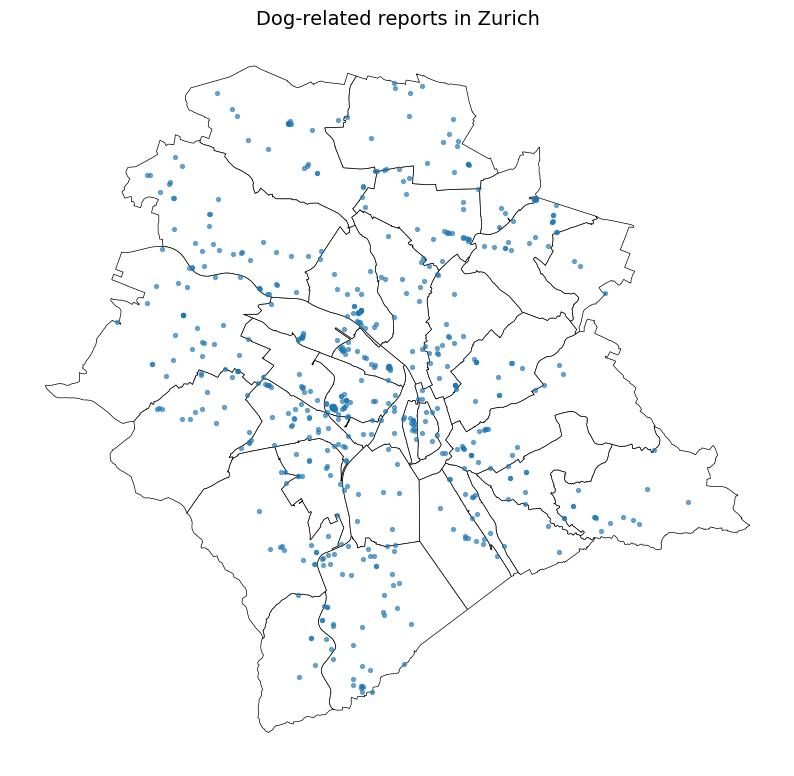

In [7]:
# (5) Which neighbourhood report the most dog-related problems? (use LLM to assess which wordings are searched in descriptions and titles)?

# 1. Normalize text of "detail"-column to make keyword search work
reports_quartier["detail"] = (
    reports_quartier["detail"]
    .fillna("") # replaces potential NaN with empty strings
    .astype(str) # ensures that all detail descriptions are text (strings)
    .str.lower() # converts all text in "detail" to lowercase
)

# 2. search for word stem "hund" but exclude "hundert(e)" using the regex syntax
hund_reports = reports_quartier[
    reports_quartier["detail"].str.contains(
        r"\b\w*hund(?!ert)\w*\b",
        regex=True
    )
].copy()

print(len(hund_reports))
display(hund_reports[["detail", "qname"]].head())

# 3. map the dog-problems

fig, ax = plt.subplots(figsize=(10, 10))

# Base map: all Zurich neighbourhood polygons
quartiere_gdf.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.5
)

# Dog-report points
hund_reports.plot(
    ax=ax,
    markersize=8,
    alpha=0.6
)

ax.set_title("Dog-related reports in Zurich", fontsize=14)
ax.axis("off")

plt.show()